In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()

video_path = next(iter(uploaded))
print("Video uploaded:", video_path)

Saving vidssave.com switzerland 4k _ switzerland 4k video _ switzerland 480p.mp4 to vidssave.com switzerland 4k _ switzerland 4k video _ switzerland 480p.mp4
Video uploaded: vidssave.com switzerland 4k _ switzerland 4k video _ switzerland 480p.mp4


In [ ]:
cap = cv2.VideoCapture(video_path)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

if not ret:
    print("Could not read video")
else:
    print("Video loaded successfully")

cap.release()

Video loaded successfully


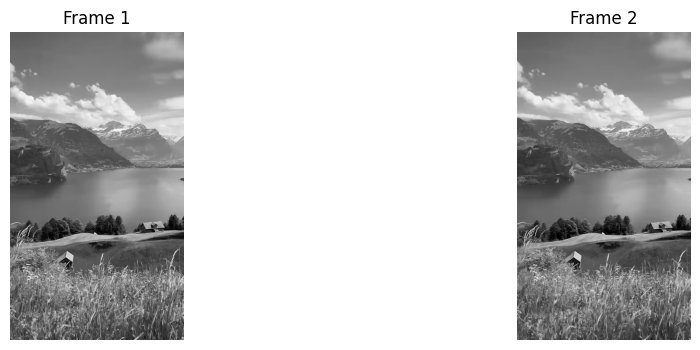

In [ ]:
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap='gray')
plt.title("Frame 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap='gray')
plt.title("Frame 2")
plt.axis("off")

plt.show()

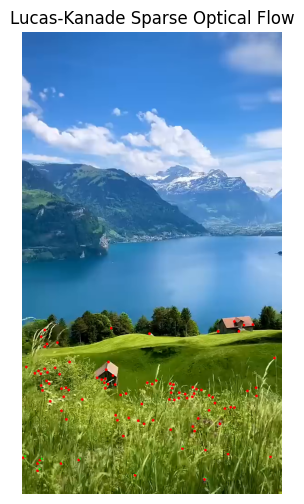

In [ ]:
# Detect feature points
features = cv2.goodFeaturesToTrack(
    gray1,
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# Lucas-Kanade parameters
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

# Calculate optical flow
next_points, status, error = cv2.calcOpticalFlowPyrLK(
    gray1, gray2, features, None, **lk_params
)

# Select good points
good_old = features[status == 1]
good_new = next_points[status == 1]

# Draw motion vectors
output = frame2.copy()

for old, new in zip(good_old, good_new):
    x1, y1 = old.ravel()
    x2, y2 = new.ravel()

    cv2.arrowedLine(
        output,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        (0, 255, 0),
        2
    )

    cv2.circle(
        output,
        (int(x2), int(y2)),
        3,
        (0, 0, 255),
        -1
    )

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.show()

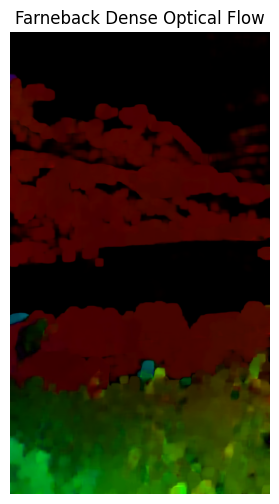

In [ ]:
flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

# Convert flow to magnitude and angle
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

# Create HSV image
hsv = np.zeros_like(frame1)
hsv[..., 1] = 255

hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

dense_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(dense_flow)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

In [ ]:
print("Optical Flow Algorithm Comparison")
print("----------------------------------")
print("Lucas-Kanade : Sparse Optical Flow")
print("Farneback     : Dense Optical Flow")
print()
print("Lucas-Kanade tracks selected feature points.")
print("Farneback estimates motion for almost every pixel.")
print("Lucas-Kanade generally requires less computation.")
print("Farneback provides more detailed motion information.")

Optical Flow Algorithm Comparison
----------------------------------
Lucas-Kanade : Sparse Optical Flow
Farneback     : Dense Optical Flow

Lucas-Kanade tracks selected feature points.
Farneback estimates motion for almost every pixel.
Lucas-Kanade generally requires less computation.
Farneback provides more detailed motion information.
